<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://raw.githubusercontent.com/carlosfab/star-research/master/assets/img/star_research_logo.png" alt="STAR Research Institute" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #1b2a4a; margin: 0; font-size: 24px;">Implementacao de Papers</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #1b2a4a; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>Ant Colony Optimization</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
<p style="color: #6c757d; margin: 2px 0 0; font-size: 13px;"><a href="https://starresearch.institute" style="color: #6c757d;">starresearch.institute</a></p>
</div>

# Introducao

Neste notebook vamos implementar o algoritmo **Ant System** a partir do paper original:

> Dorigo, M., Birattari, M. & Stutzle, T. (2006). **Ant Colony Optimization: Artificial Ants as a Computational Intelligence Technique.** IEEE Computational Intelligence Magazine, 1(4), 28-39.

O objetivo e traduzir o pseudocodigo e as equacoes do paper diretamente para Python, aplicando ao **Problema do Caixeiro Viajante (TSP)**.

### Roteiro

- **Parte 1** — Definir o problema (TSP) — Secao II-A do paper
- **Parte 2** — Implementar as equacoes-chave (Eq. 2 a 5) — Secao II-C-1, p. 32
- **Parte 3** — Montar o loop principal (Algorithm 1) — Secao II-B, p. 31
- **Parte 4** — Resultados e visualizacoes
- **Parte 5** — Experimentar com parametros

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)
print('Setup pronto.')

Setup pronto.


# Parte 1: O Problema — Caixeiro Viajante (TSP)

O paper usa o TSP como exemplo principal (Secao II-A):

> *"A set of cities is given and the distance between each of them is known. The goal is to find the shortest tour that allows each city to be visited once and only once."*

Em termos de grafo: queremos encontrar o **ciclo Hamiltoniano de menor custo** num grafo completo.

Para 20 cidades, existem $\frac{(20-1)!}{2} \approx 6 \times 10^{16}$ rotas possiveis — inviavel por forca bruta.

In [2]:
n_cidades = 20
cidades = np.random.rand(n_cidades, 2) * 100

print(f'{n_cidades} cidades geradas')
print(f'Primeira cidade: ({cidades[0, 0]:.1f}, {cidades[0, 1]:.1f})')

20 cidades geradas
Primeira cidade: (37.5, 95.1)


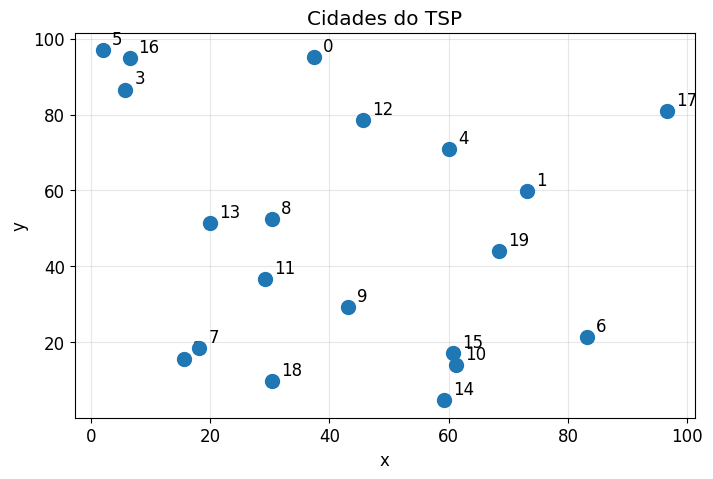

In [3]:
plt.scatter(cidades[:, 0], cidades[:, 1], s=100, zorder=5)

for i, (x, y) in enumerate(cidades):
    plt.annotate(str(i), (x + 1.5, y + 1.5))

plt.title('Cidades do TSP')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Matriz de distancias

Distancia Euclidiana entre todos os pares de cidades:

$$d_{ij} = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$

Essa matriz sera usada para calcular o custo de rotas e a informacao heuristica $\eta_{ij}$.

In [4]:
def calcular_distancias(cidades):
    n = len(cidades)
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist[i, j] = np.sqrt(np.sum((cidades[i] - cidades[j])**2))
    return dist

In [5]:
distancias = calcular_distancias(cidades)

print(f'Distancia entre cidade 0 e 1: {distancias[0, 1]:.2f}')
print(f'Distancia entre cidade 0 e 2: {distancias[0, 2]:.2f}')

Distancia entre cidade 0 e 1: 50.17
Distancia entre cidade 0 e 2: 82.42


# Parte 2: Do Paper ao Codigo

O **Algorithm 1** (Secao II-B, p. 31) descreve a metaheuristica ACO:

```
Algorithm 1: The Ant Colony Optimization Metaheuristic
    Set parameters, initialize pheromone trails
    while termination condition not met do
        ConstructAntSolutions
        ApplyLocalSearch (optional)
        UpdatePheromones
    endwhile
```

Vamos implementar cada componente a partir das equacoes do paper.

## Equacao 5 — Informacao Heuristica

A **Equacao 5** (Secao II-C-1, p. 32) define a informacao heuristica:

$$\eta_{ij} = \frac{1}{d_{ij}}$$

Quanto mais perto a cidade, maior $\eta_{ij}$ — maior a atratividade natural.

In [6]:
# Equacao 5 do paper (Secao II-C-1, p. 32)
eta = 1 / (distancias + 1e-10)

print(f'eta[0, 1] = {eta[0, 1]:.4f}  (distancia = {distancias[0, 1]:.2f})')
print(f'eta[0, 5] = {eta[0, 5]:.4f}  (distancia = {distancias[0, 5]:.2f})')

eta[0, 1] = 0.0199  (distancia = 50.17)
eta[0, 5] = 0.0282  (distancia = 35.45)


## Parametros do Ant System

| Parametro | Significado | Referencia |
|-----------|-------------|------------|
| $\alpha$ | Peso do feromonio na decisao | Eq. 4 |
| $\beta$ | Peso da heuristica na decisao | Eq. 4 |
| $\rho$ | Taxa de evaporacao (entre 0 e 1) | Eq. 2 |
| $Q$ | Constante para deposito de feromonio | Eq. 3 |
| $m$ | Numero de formigas | Algorithm 1 |

In [7]:
n_formigas = 20
n_iteracoes = 100
alpha = 1.0   # peso do feromonio (Eq. 4)
beta = 2.0    # peso da heuristica (Eq. 4)
rho = 0.5     # taxa de evaporacao (Eq. 2)
Q = 100       # constante de deposito (Eq. 3)

## Inicializar feromonio

Primeiro passo do Algorithm 1: *"Set parameters, initialize pheromone trails"*.

Valor uniforme em todas as arestas — nenhum caminho e favorecido inicialmente.

In [8]:
tau = np.ones((n_cidades, n_cidades))

print(f'Feromonio inicial entre cidade 0 e 1: {tau[0, 1]}')
print(f'Formato da matriz: {tau.shape}')

Feromonio inicial entre cidade 0 e 1: 1.0
Formato da matriz: (20, 20)


## Equacao 4 — ConstructAntSolutions

A **Equacao 4** (Secao II-C-1, p. 32) define a probabilidade de a formiga $k$, na cidade $i$, ir para a cidade $j$:

$$p_{ij}^k = \frac{\tau_{ij}^\alpha \cdot \eta_{ij}^\beta}{\sum_{l \in N_i^k} \tau_{il}^\alpha \cdot \eta_{il}^\beta} \quad \text{se } j \in N_i^k$$

onde $N_i^k$ e o conjunto de cidades ainda nao visitadas pela formiga $k$.

In [9]:
def escolher_proxima_cidade(tau, eta, cidade_atual, visitadas, alpha, beta):
    """Implementacao da Equacao 4 do paper (Secao II-C-1, p. 32)."""
    n = len(tau)
    probabilidades = np.zeros(n)

    for j in range(n):
        if j not in visitadas:
            probabilidades[j] = (
                tau[cidade_atual, j] ** alpha
                * eta[cidade_atual, j] ** beta
            )

    probabilidades /= probabilidades.sum()
    return np.random.choice(n, p=probabilidades)

Construcao da rota completa de uma formiga. Comeca em uma cidade aleatoria e escolhe a proxima (Eq. 4) ate visitar todas.

In [10]:
def construir_rota(tau, eta, n_cidades, alpha, beta):
    """Constroi uma rota completa (ConstructAntSolutions do Algorithm 1)."""
    cidade_inicial = np.random.randint(n_cidades)
    rota = [cidade_inicial]
    visitadas = {cidade_inicial}

    for _ in range(n_cidades - 1):
        proxima = escolher_proxima_cidade(
            tau, eta, rota[-1], visitadas, alpha, beta
        )
        rota.append(proxima)
        visitadas.add(proxima)

    return rota

In [11]:
rota_teste = construir_rota(tau, eta, n_cidades, alpha, beta)
print(f'Rota: {rota_teste}')
print(f'Visitou {len(rota_teste)} cidades (deve ser {n_cidades})')

Rota: [6, 14, 15, 10, 9, 5, 16, 3, 0, 12, 1, 19, 8, 13, 18, 7, 2, 11, 4, 17]
Visitou 20 cidades (deve ser 20)


## Custo de uma rota

Soma das distancias entre cidades consecutivas, incluindo a volta a cidade de origem (ciclo Hamiltoniano).

In [12]:
def custo_rota(rota, distancias):
    """Calcula o comprimento total L_k da rota (usado na Eq. 3)."""
    custo = 0
    for i in range(len(rota) - 1):
        custo += distancias[rota[i], rota[i + 1]]
    custo += distancias[rota[-1], rota[0]]
    return custo

In [13]:
custo_teste = custo_rota(rota_teste, distancias)
print(f'Custo da rota de teste: {custo_teste:.2f}')

Custo da rota de teste: 543.14


## Equacoes 2 e 3 — UpdatePheromones

A **Equacao 2** (Secao II-C-1, p. 32) define a atualizacao do feromonio:

$$\tau_{ij} \leftarrow (1 - \rho) \cdot \tau_{ij} + \sum_{k=1}^{m} \Delta\tau_{ij}^k$$

A **Equacao 3** define o deposito de cada formiga:

$$\Delta\tau_{ij}^k = \begin{cases} Q / L_k & \text{se a formiga } k \text{ usou a aresta } (i, j) \\ 0 & \text{caso contrario} \end{cases}$$

Dois mecanismos: **evaporacao** ($(1-\rho) \cdot \tau_{ij}$) faz o feromonio decair, e **deposito** ($\Delta\tau_{ij}^k$) reforca arestas de boas rotas.

In [14]:
def atualizar_feromonio(tau, rotas, custos, rho, Q):
    """Implementacao das Equacoes 2 e 3 do paper (Secao II-C-1, p. 32)."""
    # Evaporacao (primeiro termo da Eq. 2)
    tau *= (1 - rho)

    # Deposito de feromonio por cada formiga (Eq. 3)
    for rota, custo in zip(rotas, custos):
        deposito = Q / custo
        for i in range(len(rota) - 1):
            tau[rota[i], rota[i + 1]] += deposito
            tau[rota[i + 1], rota[i]] += deposito
        # Fechar o ciclo
        tau[rota[-1], rota[0]] += deposito
        tau[rota[0], rota[-1]] += deposito

# Parte 3: O Loop Principal

Montagem do **Algorithm 1** completo:

| Paper (Algorithm 1, p. 31) | Codigo |
|----------------------------|--------|
| Set parameters, initialize pheromone trails | Parametros e `tau` definidos acima |
| while termination condition not met | `for iteracao in range(n_iteracoes)` |
| ConstructAntSolutions | `construir_rota()` |
| UpdatePheromones | `atualizar_feromonio()` |

In [15]:
tau = np.ones((n_cidades, n_cidades))

melhor_rota = None
melhor_custo = float('inf')
historico = []

In [16]:
for iteracao in range(n_iteracoes):

    # ConstructAntSolutions
    rotas = []
    custos = []
    for _ in range(n_formigas):
        rota = construir_rota(tau, eta, n_cidades, alpha, beta)
        custo = custo_rota(rota, distancias)
        rotas.append(rota)
        custos.append(custo)

        if custo < melhor_custo:
            melhor_custo = custo
            melhor_rota = rota[:]

    # UpdatePheromones
    atualizar_feromonio(tau, rotas, custos, rho, Q)
    historico.append(melhor_custo)

print(f'Melhor custo: {melhor_custo:.2f}')

Melhor custo: 388.20


# Parte 4: Resultados

## Curva de convergencia

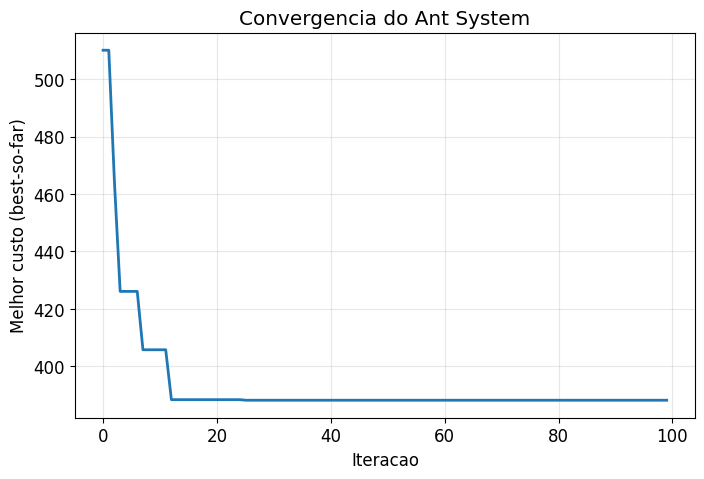

In [17]:
plt.plot(historico)
plt.xlabel('Iteracao')
plt.ylabel('Melhor custo (best-so-far)')
plt.title('Convergencia do Ant System')
plt.show()

## Melhor rota encontrada

In [18]:
def plotar_rota(cidades, rota, titulo='Melhor rota'):
    rota_completa = rota + [rota[0]]
    coords = cidades[rota_completa]

    plt.plot(coords[:, 0], coords[:, 1], 'o-', markersize=8)
    plt.plot(coords[0, 0], coords[0, 1], 'rs', markersize=12, label='Origem')

    for i, (x, y) in enumerate(cidades):
        plt.annotate(str(i), (x + 1.5, y + 1.5))

    plt.title(titulo)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()

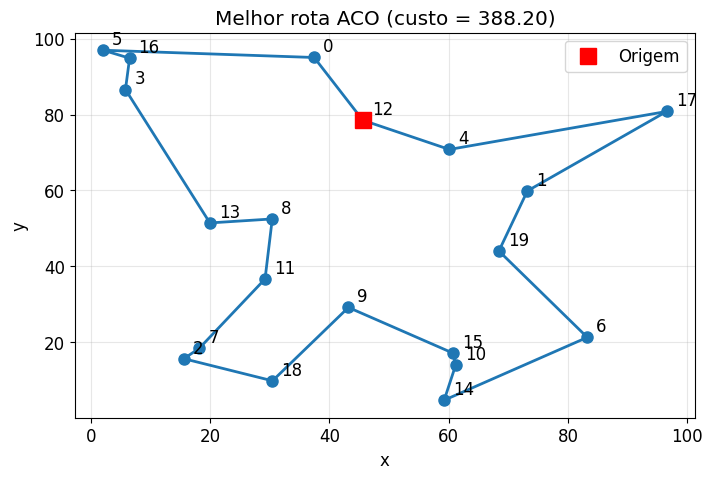

In [19]:
plotar_rota(cidades, melhor_rota, f'Melhor rota ACO (custo = {melhor_custo:.2f})')

## Mapa de feromonio

Cada aresta e desenhada com espessura proporcional ao feromonio acumulado. Arestas mais grossas indicam caminhos mais reforçados pelas formigas.

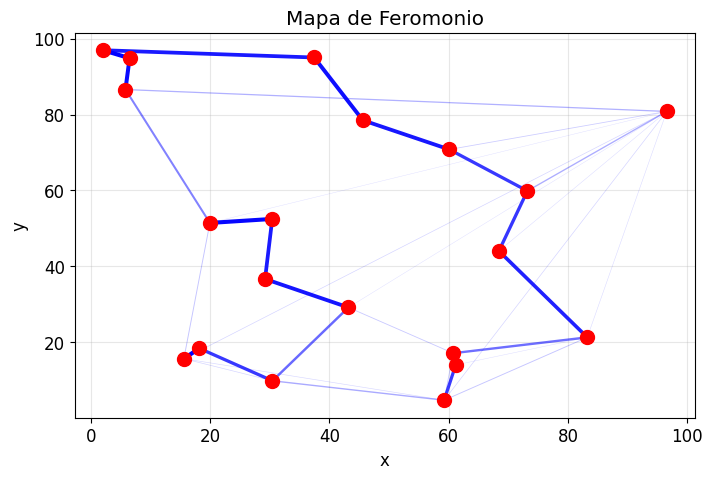

In [20]:
plt.scatter(cidades[:, 0], cidades[:, 1], s=100, zorder=5, color='red')

tau_norm = tau / tau.max()
for i in range(n_cidades):
    for j in range(i + 1, n_cidades):
        if tau_norm[i, j] > 0.1:
            plt.plot(
                [cidades[i, 0], cidades[j, 0]],
                [cidades[i, 1], cidades[j, 1]],
                'b-', alpha=tau_norm[i, j],
                linewidth=tau_norm[i, j] * 3,
            )

plt.title('Mapa de Feromonio')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Comparacao com rota aleatoria

In [21]:
rota_aleatoria = list(np.random.permutation(n_cidades))
custo_aleatorio = custo_rota(rota_aleatoria, distancias)

print(f'Custo rota aleatoria: {custo_aleatorio:.2f}')
print(f'Custo rota ACO:       {melhor_custo:.2f}')
print(f'Melhoria:             {(1 - melhor_custo / custo_aleatorio) * 100:.1f}%')

Custo rota aleatoria: 1208.85
Custo rota ACO:       388.20
Melhoria:             67.9%


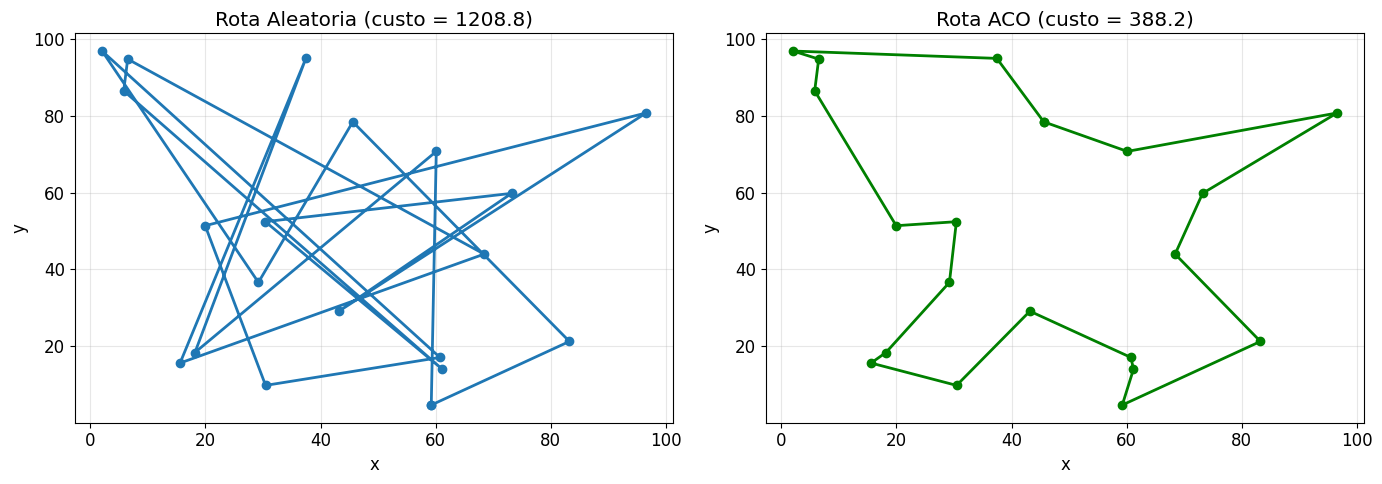

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rota_comp = rota_aleatoria + [rota_aleatoria[0]]
coords = cidades[rota_comp]
axes[0].plot(coords[:, 0], coords[:, 1], 'o-', markersize=6)
axes[0].set_title(f'Rota Aleatoria (custo = {custo_aleatorio:.1f})')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

rota_comp = melhor_rota + [melhor_rota[0]]
coords = cidades[rota_comp]
axes[1].plot(coords[:, 0], coords[:, 1], 'o-', markersize=6, color='green')
axes[1].set_title(f'Rota ACO (custo = {melhor_custo:.1f})')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Parte 5: Experimentando com Parametros

Lembrando a Eq. 4: $p_{ij} \propto \tau_{ij}^\alpha \cdot \eta_{ij}^\beta$

- $\alpha = 1, \beta = 1$: balanco igual entre feromonio e distancia
- $\alpha = 1, \beta = 5$: mais peso na distancia (guloso, explora menos)
- $\alpha = 5, \beta = 1$: mais peso no feromonio (efeito rebanho)

In [23]:
def rodar_aco(cidades, n_formigas, n_iteracoes, alpha, beta, rho, Q):
    """Executa o Ant System completo."""
    n = len(cidades)
    dist = calcular_distancias(cidades)
    eta = 1 / (dist + 1e-10)
    tau = np.ones((n, n))

    melhor_rota = None
    melhor_custo = float('inf')
    historico = []

    for _ in range(n_iteracoes):
        rotas, custos = [], []
        for _ in range(n_formigas):
            rota = construir_rota(tau, eta, n, alpha, beta)
            custo = custo_rota(rota, dist)
            rotas.append(rota)
            custos.append(custo)
            if custo < melhor_custo:
                melhor_custo = custo
                melhor_rota = rota[:]
        atualizar_feromonio(tau, rotas, custos, rho, Q)
        historico.append(melhor_custo)

    return melhor_rota, melhor_custo, historico

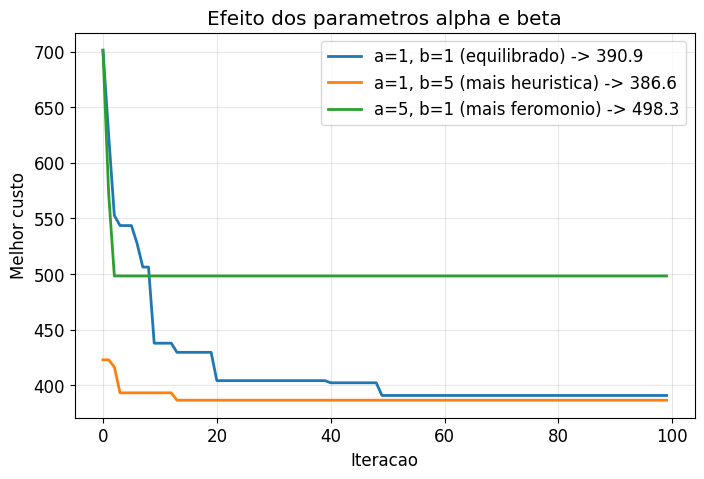

In [24]:
configs = [
    {'alpha': 1, 'beta': 1, 'label': 'a=1, b=1 (equilibrado)'},
    {'alpha': 1, 'beta': 5, 'label': 'a=1, b=5 (mais heuristica)'},
    {'alpha': 5, 'beta': 1, 'label': 'a=5, b=1 (mais feromonio)'},
]

for cfg in configs:
    np.random.seed(42)
    _, custo, hist = rodar_aco(
        cidades, 20, 100, cfg['alpha'], cfg['beta'], 0.5, 100
    )
    plt.plot(hist, label=f"{cfg['label']} -> {custo:.1f}")

plt.xlabel('Iteracao')
plt.ylabel('Melhor custo')
plt.title('Efeito dos parametros alpha e beta')
plt.legend()
plt.show()

### Analise

- **a=1, b=5 (guloso):** converge rapido, mas tende a ficar preso em solucoes locais.
- **a=5, b=1 (rebanho):** inicio lento (feromonio uniforme), depois estagna quando uma rota domina.
- **a=1, b=2 (nosso padrao):** equilibrio empirico amplamente usado na literatura.

# Recapitulando

### Mapeamento Paper -> Codigo

| Paper | Codigo |
|-------|--------|
| Algorithm 1 (p. 31) | Loop principal |
| Equacao 2 (p. 32) | `atualizar_feromonio()` — evaporacao + deposito |
| Equacao 3 (p. 32) | `atualizar_feromonio()` — deposito $Q/L_k$ |
| Equacao 4 (p. 32) | `escolher_proxima_cidade()` — regra de transicao probabilistica |
| Equacao 5 (p. 32) | `eta = 1 / distancias` — informacao heuristica |

### Referencia

Dorigo, M., Birattari, M. & Stutzle, T. (2006). *Ant Colony Optimization: Artificial Ants as a Computational Intelligence Technique.* IEEE Computational Intelligence Magazine, 1(4), 28-39.